# Projeto "Detecção de anomalias em transações em Python"

## Importação e leitura dos dados

Carregamento dos dados via URL utilizando Pandas. As variáveis originais (V1 a V28) estão anonimizadas para proteger a privacidade e segurança dos clientes. Para termos uma visão prévia dos dados, utilizamos a função head(), que mostra as primeiras cinco linhas do arquivo .csv.

In [5]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Balenceando a classificação

In [6]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Nota-se que há um número muito pequeno de transações que são fraudulentas, em comparação com o total. Treinar um modelo com os dados sem um tratamento prévio poderá levar a erros, como ignorar operações as fraudulentas (representaddas por "1" na última coluna). Neste caso, teremos um modelo que não identifica fraudes. Precisamos utilizar métricas e tratamentos específicos.

## Feature Engineering

#### Criando variáveis que ajudam o modelo a aprender


In [12]:
import numpy as np

df["Amount_log"] = np.log1p(df["Amount"])

O valor das transações, representado pela coluna "Amount" é muito diverso. Alguns bem pequenos, outros bem maiores. Isso pode ser um problema na aprendizagem de máquina, que pode dar uma "importância" maior aos números maiores, trazendo um peso para a variável que muitas vezes não é o ideal. Por isso a necessidade de seu balancemento.

In [ ]:
# Colocando valores na mesma escala
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [14]:
from sklearn.model_selection import train_test_split

x = df.drop("Class", axis=1)
y = df["Class"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.3, random_state=42
)

X = features
Y = targets

Dividindo os dados em conjuntos de treino e de teste. O stratify garante que no treino e no teste o número de operações fraudulentas seja o mesmo.

## Avaliação dos modelos

O primeiro algoritmo testado é a Regressão Logística, que atinge um recall de 64% (ou seja, detecta cerca de 64% das fraudes reais). O desempenho é ilustrado com curvas ROC e Precision-Recall, mostrando visualmente como o modelo se torna mais impreciso ao tentar abraçar um número maior de fraudes.

### Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)



c:\Users\Marco\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### Encontrando padrões de teste

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.64      0.73       148

    accuracy                           1.00     85443
   macro avg       0.93      0.82      0.87     85443
weighted avg       1.00      1.00      1.00     85443



O modelo conseguiu identificar apenas 64% das fraudes reais

### ROC Curve:

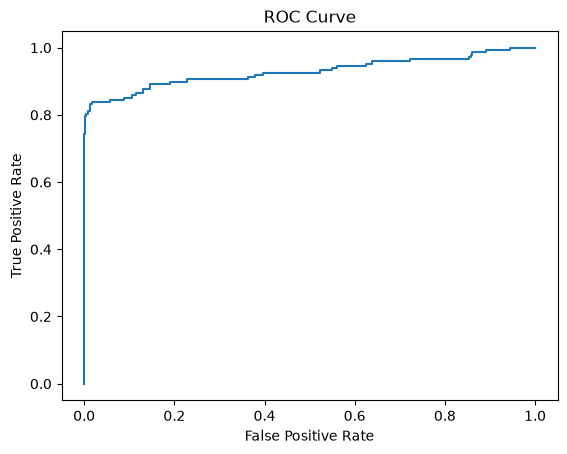

AUC: 0.9283981824605543


In [17]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

### Precision-Recall Curve

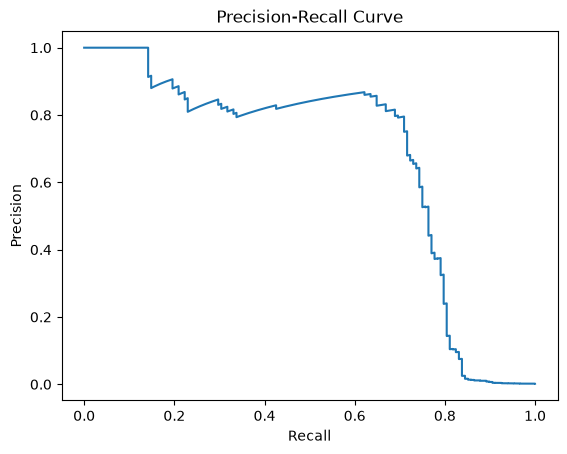

In [19]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

Em um baixo número de recall, o modelo se mostra mais conservador. Ao aumentar o número de recall, a precisão do modelo baixa e começa a marcar transações que não são fraudulentas como fraudulentas.

## Balanceamento de dados

O código abaixo prepara o terreno para resolver o desbalanceamento utilizando Undersampling (cortar transações normais para igualar as fraudes) e Oversampling através do SMOTE (criar fraudes sintéticas para ensinar o padrão ao modelo).

In [20]:
# Undersamplin
fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

In [22]:
# Oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE()

x_res, y_res = smote.fit_resample(x, y)

### Random Forest

O modelo Random Forest é treinado com o parâmetro class_weight="balanced". Isso faz o algoritmo dar mais atenção às fraudes.

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.74      0.80      0.77       148

    accuracy                           1.00     85443
   macro avg       0.87      0.90      0.89     85443
weighted avg       1.00      1.00      1.00     85443



Podemos perceber que, de 64% de transações fraudulentas identificadas com o uso de logic regression, passamos para 80% com o uso de Random Forest. 

Agora vamos testar um Pipeline que organiza o fluxo de pré-processamento e o ajuste manual do limiar de decisão (threshold)

In [27]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

In [28]:
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.81      0.68      0.74       148

    accuracy                           1.00     85443
   macro avg       0.91      0.84      0.87     85443
weighted avg       1.00      1.00      1.00     85443



### Um modelo mais avançado - XGBoost

Com o XGBoost, um algoritmo preditivo muito poderoso, usamos scale_pos_weight=10 para penalizar os erros nas fraudes. Ele apresenta métricas excelentes e equilibradas (recall de 78% e e uma alta precisão de 94%).

In [31]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    scale_pos_weight=10, # ajuda com desbalanceamento
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

c:\Users\Marco\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:06:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [32]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



## Importância das variáveis

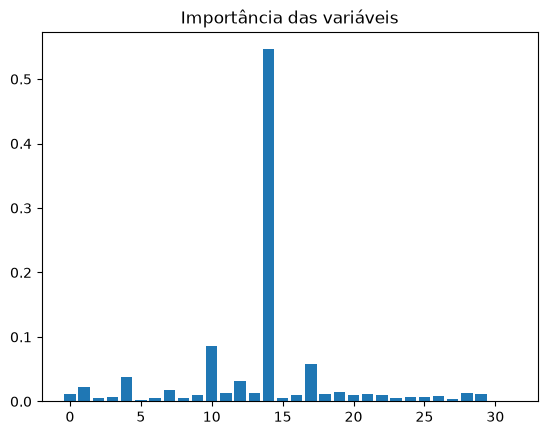

In [33]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()

### Ajuste de hiperparâmetros

O projeto utiliza o GridSearchCV para rodar várias combinações de hiperparâmetros no XGBoost, descobrindo que 100 árvores (n_estimators) com profundidade 5 (max_depth) entregam o melhor recall.

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(x_train, y_train)

print("Melhor modelo:", grid.best_params_)

Melhor modelo: {'max_depth': 5, 'n_estimators': 100}


### Explicabilidade (SHAP)

Aqui vemos quais variáveis são mais importantes para cada modelo, ou seja, quais têm um peso maior na classificação de fraudes. A biblioteca SHAP é gerada para plotar um gráfico mostrando a ordem de importância de cada variável oculta nas decisões da máquina. Este é um ponto muito importante para eventuais auditorias futuras.

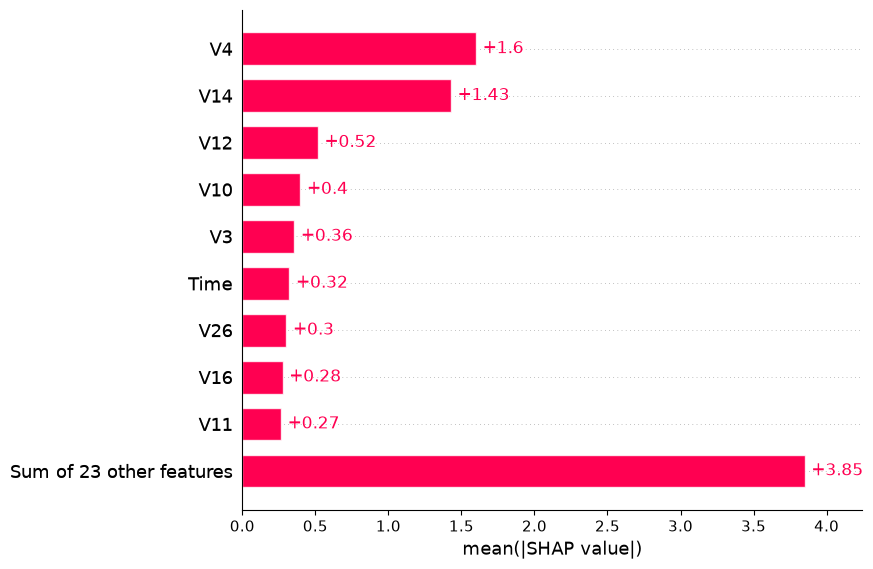

In [39]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(x_test[:100])

shap.plots.bar(shap_values)